In [40]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import glob
import scipy.optimize as so
import astropy.constants as c
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp
from matplotlib.collections import LineCollection, PolyCollection
from matplotlib import cm, colors
import matplotlib.animation as animation
plt.rcParams['figure.dpi'] = 100
print(sys.path)
from pprint import pprint 
import pandas as pd
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.collections import PolyCollection

['/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/SpecFANN', '/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/anaconda3/envs/spamms/lib/python310.zip', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/lib-dynload', '', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/site-packages', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS']


In [4]:
input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input.txt'
fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)
run_dictionaries = sp.create_runs_and_ids(fit_param_values)

Reading input file...


In [5]:
run_dictionary = run_dictionaries[1] # CHANGE THIS TO SELECT WHICH MODEL TO PLOT If using the unchanged input file, 0 is no rotation, 1 is 0.25 crit, and 2 is 0.9 crit
s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
run_dictionary

100%|██████████| 2/2 [00:20<00:00, 10.46s/it]


{'v_macro': -1.0,
 'sigma_R': 200.0,
 'sigma_T': 200.0,
 'teff': 40000.0,
 'vsini': -1.0,
 'rotation_rate': -1.0,
 'v_crit_frac': 0.9,
 'requiv': -1.0,
 'r_pole': 6.5,
 'inclination': 90.0,
 'mass': 25.0,
 't0': 0.0,
 'gamma': 0.0,
 'run_id': 1}

In [9]:
phcb = s['%09.6f'%s['times@dataset@lc'].value]

verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
teffs = phcb['mesh@primary@mesh01@teffs'].get_value()
mus = phcb['mesh@primary@mesh01@mus'].get_value()
rvs = phcb['rvs@primary@mesh'].get_value()

xs = verts[:, :, 0]
ys = verts[:, :, 1]
zs = verts[:, :, 2]
print(xs.shape, ys.shape, zs.shape) 

(22632, 3) (22632, 3) (22632, 3)


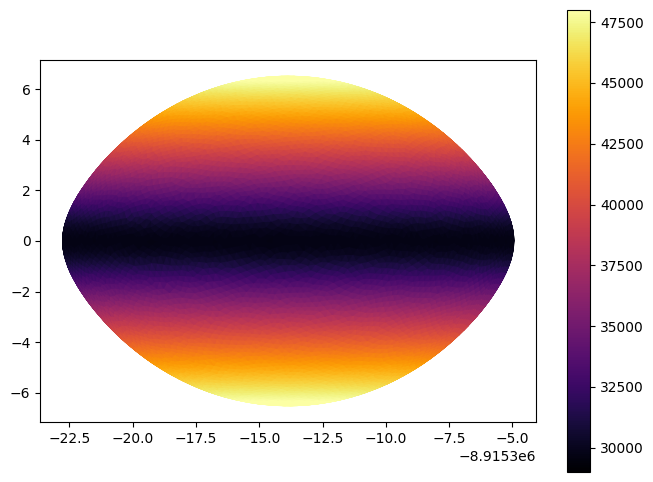

In [10]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = teffs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.inferno(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.inferno(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='inferno'), ax=axs)
plt.show()

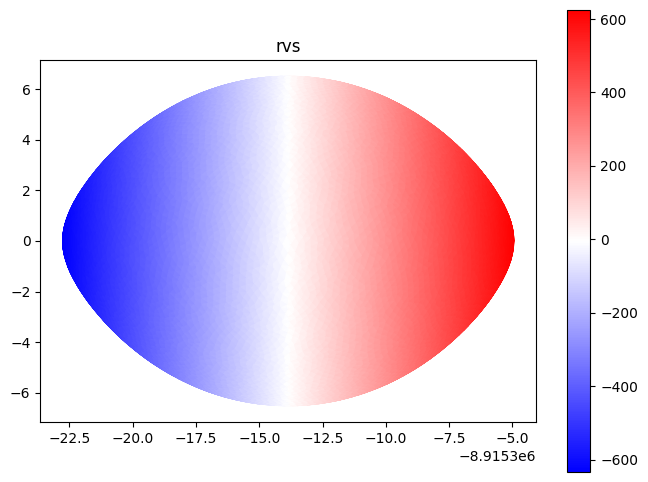

In [8]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = rvs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('rvs')
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors

polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)
viss = phcb['visibilities@primary'].get_value()
inds = viss > 0
z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

rng = np.random.default_rng(30)
sigma_T = rng.normal(0, 100, size=mus.shape[0])
sigma_R = rng.normal(0, 100, size=mus.shape[0]) 
theta_T = rng.uniform(0, 2*np.pi, size=mus.shape[0])
theta_mu = np.arccos(np.clip(mus, -1, 1))
v_T =  sigma_T * np.sin(theta_mu) * np.cos(theta_T)
v_R =  sigma_R * mus


/tmp/ipykernel_7172/2942348384.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr")


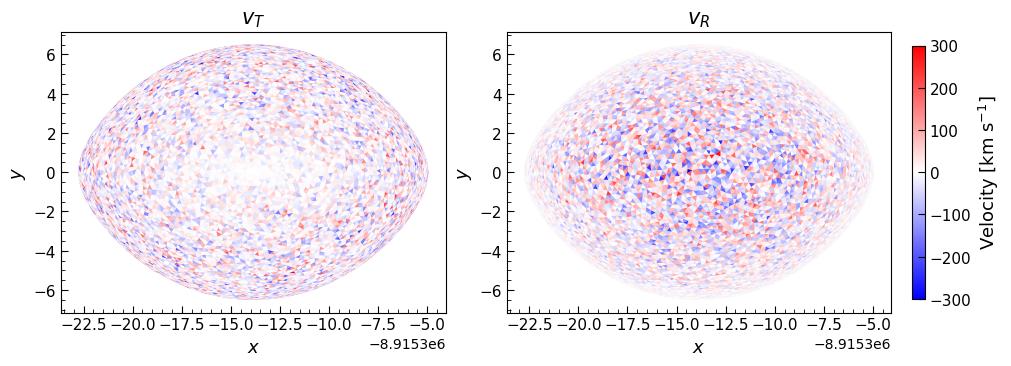

In [28]:
velocities = [v_T, v_R]
titles = [r"$v_T$", r"$v_R$"]
vmax = np.nanmax([np.nanmax(np.abs(v[inds])) for v in velocities])
norm = colors.Normalize(vmin=-300, vmax=300)
cmap = cm.get_cmap("bwr")
def add_velocity_panel(ax, fc, title):
    pc = PolyCollection(
        polygons[inds][zinds],
        facecolors=cmap(norm(fc[inds][zinds])),
        edgecolors=cmap(norm(fc[inds][zinds])),
        linewidths=0.12)
    ax.add_collection(pc)
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(r"$x$", fontsize=13)
    ax.set_ylabel(r"$y$", fontsize=13)
    ax.tick_params(axis="both", which="major", labelsize=11, direction="in", length=5)
    ax.tick_params(axis="both", which="minor", direction="in", length=3)
    ax.minorticks_on()
    return pc

fig, axes = plt.subplots(1, 2, figsize=(10, 8), constrained_layout=True)
for ax, fc, title in zip(axes, velocities, titles):
    add_velocity_panel(ax, fc, title)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.5,
    pad=0.025,
    shrink=0.32)
cbar.set_label(r"Velocity [km s$^{-1}$]", fontsize=13)
cbar.ax.tick_params(labelsize=11, direction="in", length=5)
plt.show()

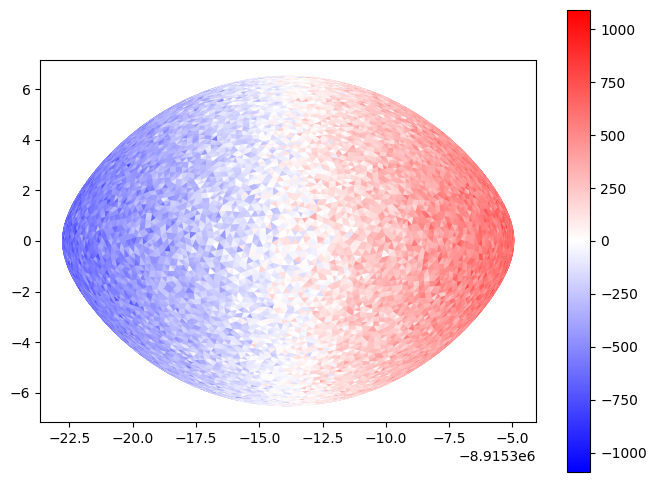

In [29]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T + rvs
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.show()

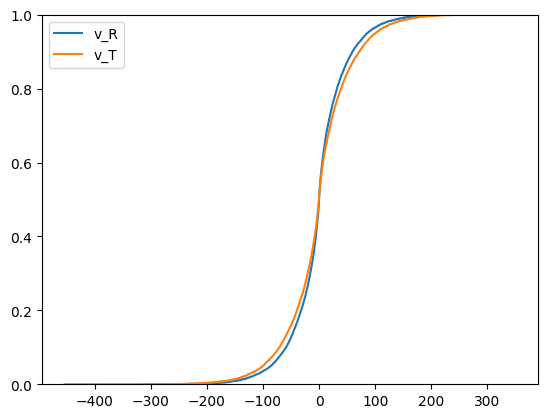

In [30]:
plt.ecdf(v_R, label='v_R')
plt.ecdf(v_T, label='v_T')
plt.legend(loc='upper left')
plt.show()

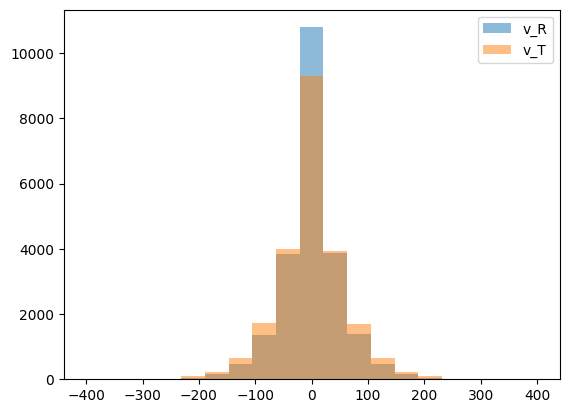

In [31]:
bins = np.linspace(-400, 400, 20)
plt.hist(v_R, alpha=0.5, bins=bins, label='v_R')
plt.hist(v_T, alpha=0.5, bins=bins, label='v_T')
plt.legend(loc='upper right')
plt.show()

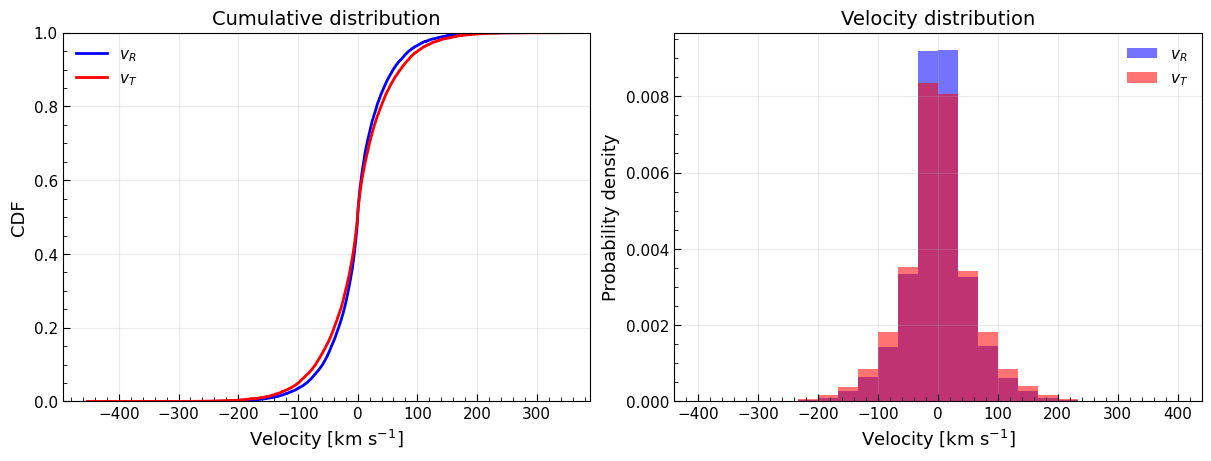

In [36]:
bins = np.linspace(-400, 400, 25)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].ecdf(v_R, label=r"$v_R$", linewidth=2.0, color = 'b')
axes[0].ecdf(v_T, label=r"$v_T$", linewidth=2.0, color = 'r')
axes[0].set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=13)
axes[0].set_ylabel("CDF", fontsize=13)
axes[0].set_title("Cumulative distribution", fontsize=14)
axes[0].legend(loc="upper left", fontsize=11, frameon=False)
axes[0].tick_params(axis="both", which="major", labelsize=11, direction="in", length=5)
axes[0].tick_params(axis="both", which="minor", direction="in", length=3)
axes[0].minorticks_on()
axes[0].grid(alpha=0.25)

axes[1].hist(v_R, bins=bins, alpha=0.55, label=r"$v_R$", density=True, color = 'b')
axes[1].hist(v_T, bins=bins, alpha=0.55, label=r"$v_T$", density=True, color = 'r')
axes[1].set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=13)
axes[1].set_ylabel("Probability density", fontsize=13)
axes[1].set_title("Velocity distribution", fontsize=14)
axes[1].legend(loc="upper right", fontsize=11, frameon=False)
axes[1].tick_params(axis="both", which="major", labelsize=11, direction="in", length=5)
axes[1].tick_params(axis="both", which="minor", direction="in", length=3)
axes[1].minorticks_on()
axes[1].grid(alpha=0.25)
plt.show()

In [38]:
def plot_dynamic_heatmap( df, xaxis="inclination", yaxis="v_crit_frac", cbar_quantity="mean_sigma_vR_vis", cmap="viridis", figsize=(8, 6),
    xlabel=None, ylabel=None, cbar_label=None, title=None, symmetric_cbar=False, vmin=None,vmax=None):

    d = df.copy()
    if callable(cbar_quantity):
        d["plot_value"] = cbar_quantity(d)
        value_name = "custom quantity"
    else:
        d["plot_value"] = d[cbar_quantity]
        value_name = cbar_quantity
    grid = d.pivot( index=yaxis, columns=xaxis, values="plot_value")
    xvals = grid.columns.values
    yvals = grid.index.values
    values = grid.values
    if vmin is not None or vmax is not None:
        final_vmin = vmin
        final_vmax = vmax
    elif symmetric_cbar:
        absmax = np.nanmax(np.abs(values))
        final_vmin = -absmax
        final_vmax = absmax
    else:
        final_vmin = None
        final_vmax = None

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow( values, origin="lower", aspect="auto", cmap=cmap, extent=[ xvals.min(), xvals.max(), yvals.min(), yvals.max()], vmin=final_vmin, vmax=final_vmax)
    ax.set_xlabel( xlabel if xlabel else xaxis, fontsize=15)
    ax.set_ylabel( ylabel if ylabel else yaxis, fontsize=15)
    ax.tick_params(axis="both", which="major",labelsize=13,length=6,width=1.3)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label( cbar_label if cbar_label else value_name,fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    if title is None:
        title = value_name
    plt.tight_layout()
    plt.show()

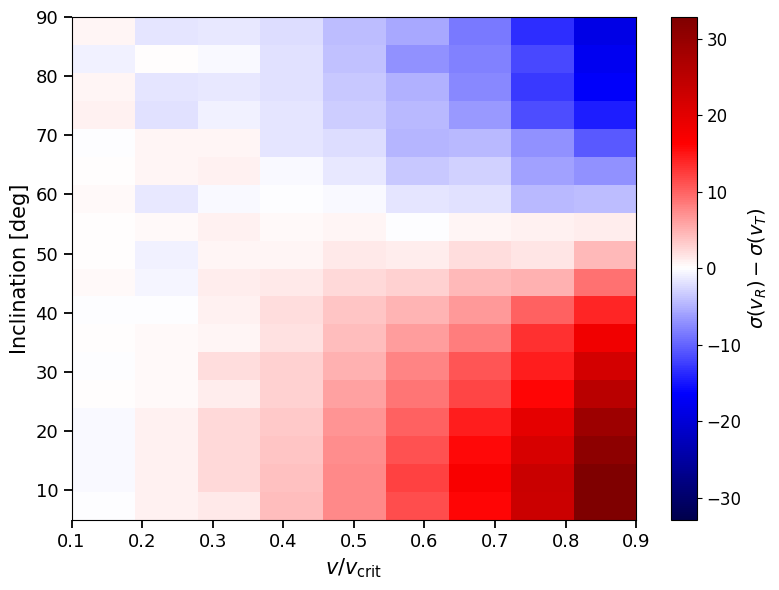

In [39]:
df = pd.read_csv('/home/c4011027/PhD_stuff/SPAMMS/Outputs/inclination_vcrit_sigma_grid.csv')
plot_dynamic_heatmap( df, xaxis="v_crit_frac", yaxis="inclination",
    cbar_quantity=lambda d: ( d["mean_sigma_vR_vis"] - d["mean_sigma_vT_vis"]),
    xlabel=r"$v/ v_{\mathrm{crit}}$" , ylabel= "Inclination [deg]",
    cbar_label=r"$\sigma(v_R) - \sigma(v_T)$",
    cmap="seismic",
    symmetric_cbar=True)

In [41]:
def ecdf_xy(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def gaussian_pdf(x, sigma0):
    return np.exp(-0.5 * (x / sigma0)**2) / (sigma0 * np.sqrt(2*np.pi))

def make_phoebe_case(sp, input_file, inclination, v_crit_frac, sigma0=250.0, seed=30):
    fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
    times, obs_specs = sp.get_obs_spec_and_times(io_dict)
    fit_params_this = copy.deepcopy(fit_param_values)
    fit_params_this["inclination"] = [float(inclination)]
    fit_params_this["v_crit_frac"] = [float(v_crit_frac)]
    run_dictionary = sp.create_runs_and_ids(fit_params_this)[0]
    print("Running model:")
    print(run_dictionary)
    s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
    phcb = s["%09.6f" % s["times@dataset@lc"].value]
    verts = phcb["mesh@primary@mesh01@uvw_elements"].get_value()
    mus = phcb["mesh@primary@mesh01@mus"].get_value()
    rvs = phcb["rvs@primary@mesh"].get_value()
    viss = phcb["visibilities@primary"].get_value()
    ws = phcb["ws@primary"].get_value()
    xs = verts[:, :, 0]
    ys = verts[:, :, 1]

    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)
    inds = viss > 0
    zinds = np.argsort(ws[inds])
    rng = np.random.default_rng(seed)
    sigma_R = rng.normal(0.0, sigma0, size=mus.shape[0])
    sigma_T = rng.normal(0.0, sigma0, size=mus.shape[0])
    theta_T = rng.uniform(0, 2*np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1, 1))
    v_R = sigma_R * mus
    v_T = sigma_T * np.sin(theta_mu) * np.cos(theta_T)
    v_tot = rvs + v_R + v_T

    return {
        "inclination": inclination,
        "v_crit_frac": v_crit_frac,
        "sigma0": sigma0,
        "run_dictionary": run_dictionary,
        "phcb": phcb,
        "polygons": polygons,
        "inds": inds,
        "zinds": zinds,
        "mus": mus,
        "rvs": rvs,
        "sigma_R_input": sigma_R,
        "sigma_T_input": sigma_T,
        "v_R": v_R,
        "v_T": v_T,
        "v_tot": v_tot,
    }


def plot_dynamic_heatmap_ax(ax, df, xaxis="inclination", yaxis="v_crit_frac", cbar_quantity="mean_sigma_vR_vis",
    cmap="viridis", xlabel=None, ylabel=None, cbar_label=None, title=None, symmetric_cbar=False,
    vmin=None, vmax=None, sample_points=None):
    d = df.copy()
    if callable(cbar_quantity):
        d["plot_value"] = cbar_quantity(d)
        value_name = "custom quantity"
    else:
        d["plot_value"] = d[cbar_quantity]
        value_name = cbar_quantity
    grid = d.pivot(index=yaxis, columns=xaxis, values="plot_value")
    xvals = grid.columns.values
    yvals = grid.index.values
    values = grid.values
    if vmin is not None or vmax is not None:
        final_vmin, final_vmax = vmin, vmax
    elif symmetric_cbar:
        absmax = np.nanmax(np.abs(values))
        final_vmin, final_vmax = -absmax, absmax
    else:
        final_vmin, final_vmax = None, None
    im = ax.imshow(values, origin="lower", aspect="auto", cmap=cmap,
                   extent=[xvals.min(), xvals.max(), yvals.min(), yvals.max()],
                   vmin=final_vmin, vmax=final_vmax)
    ax.set_xlabel(xlabel if xlabel else xaxis, fontsize=13)
    ax.set_ylabel(ylabel if ylabel else yaxis, fontsize=13)
    ax.tick_params(axis="both", which="major", labelsize=11, length=5, width=1.2, direction="in")
    ax.tick_params(axis="both", which="minor", length=3, width=1.0, direction="in")
    ax.minorticks_on()
    if title is not None:
        ax.set_title(title, fontsize=14)
    if sample_points is not None:
        for point in sample_points:
            ax.scatter(point["v_crit_frac"], point["inclination"], s=75,
                       facecolors="none", edgecolors="white", linewidths=1.8, zorder=5)
            ax.text(point["v_crit_frac"] + 0.015, point["inclination"] + 1.5, point["label"],
                    color="white", fontsize=11, weight="bold", zorder=6)
    return im, cbar_label if cbar_label else value_name


def plot_input_distribution(ax, sigma0=250.0, seed=1234):
    rng = np.random.default_rng(seed)
    sigma_ref = rng.normal(0.0, sigma0, size=50000)
    bins = np.linspace(-4*sigma0, 4*sigma0, 45)
    ax.hist(sigma_ref, bins=bins, density=True, alpha=0.55, histtype="stepfilled",
            label=rf"$\sigma_R,\sigma_T \sim \mathcal{{N}}(0,{sigma0:.0f})$")
    x = np.linspace(-4*sigma0, 4*sigma0, 500)
    ax.plot(x, gaussian_pdf(x, sigma0), lw=2.0, color="black", label="Gaussian PDF")
    ax.set_xlabel(r"Input velocity draw [km s$^{-1}$]", fontsize=13)
    ax.set_ylabel("Probability density", fontsize=13)
    ax.set_title("(b) Input distribution", fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=11, length=5, width=1.2, direction="in")
    ax.tick_params(axis="both", which="minor", length=3, width=1.0, direction="in")
    ax.minorticks_on()
    ax.legend(fontsize=10, frameon=False)
    return sigma_ref


def plot_surface_panel(ax, case, norm, cmap="bwr", title=None):
    fc = case["v_tot"]
    inds = case["inds"]
    zinds = case["zinds"]
    polygons = case["polygons"]
    cmap_obj = cm.get_cmap(cmap)
    pc = PolyCollection(
        polygons[inds][zinds],
        facecolors=cmap_obj(norm(fc[inds][zinds])),
        edgecolors=cmap_obj(norm(fc[inds][zinds])),
        linewidths=0.12)
    ax.add_collection(pc)
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xlabel(r"$x$", fontsize=9)
    ax.set_ylabel(r"$y$", fontsize=9)
    ax.tick_params(axis="both", which="major", labelsize=8, length=4, width=1.0, direction="in")
    ax.tick_params(axis="both", which="minor", length=2, width=0.8, direction="in")
    ax.minorticks_on()
    if title is not None:
        ax.set_title(title, fontsize=11)
    return pc


def plot_cdf_panel(ax, case, sigma_ref):
    inds = case["inds"]
    x_in, y_in = ecdf_xy(sigma_ref)
    x_r, y_r = ecdf_xy(case["v_R"][inds])
    x_t, y_t = ecdf_xy(case["v_T"][inds])
    ax.plot(x_in, y_in, lw=1.5, ls="--", color="black", label=r"input $\sigma$")
    ax.plot(x_r, y_r, lw=1.4, label=r"$v_R$")
    ax.plot(x_t, y_t, lw=1.4, label=r"$v_T$")
    ax.set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=9)
    ax.set_ylabel("CDF", fontsize=9)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", which="major", labelsize=8, length=4, width=1.0, direction="in")
    ax.tick_params(axis="both", which="minor", length=2, width=0.8, direction="in")
    ax.minorticks_on()
    ax.legend(fontsize=7, frameon=False, loc="lower right", ncol=3)


def plot_sigma_projection_summary(sp, input_file, df_csv, sample_cases, sigma0=250.0, seed=30,
    figsize=(13.5, 15.0)):

    df = pd.read_csv(df_csv)
    cases = []
    for case in sample_cases:
        out = make_phoebe_case(
            sp=sp,
            input_file=input_file,
            inclination=case["inclination"],
            v_crit_frac=case["v_crit_frac"],
            sigma0=sigma0,
            seed=seed)
        out["label"] = case["label"]
        cases.append(out)
    vmax_geom = np.nanmax([np.nanmax(np.abs(case["v_tot"][case["inds"]])) for case in cases])
    geom_norm = colors.Normalize(vmin=-vmax_geom, vmax=vmax_geom)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    outer = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.15, 1.15])


    ax_heat = fig.add_subplot(outer[0, 0]) #heatmap
    im, heat_cbar_label = plot_dynamic_heatmap_ax(
        ax_heat,
        df,
        xaxis="v_crit_frac",
        yaxis="inclination",
        cbar_quantity=lambda d: d["mean_sigma_vR_vis"] - d["mean_sigma_vT_vis"],
        xlabel=r"$v / v_{\mathrm{crit}}$",
        ylabel="Inclination [deg]",
        cbar_label=r"$\sigma(v_R) - \sigma(v_T)$",
        cmap="seismic",
        symmetric_cbar=True,
        title=r"(a) Visible projected-dispersion difference",
        sample_points=sample_cases)
    cbar_heat = fig.colorbar(im, ax=ax_heat, shrink=0.85, pad=0.02)
    cbar_heat.set_label(heat_cbar_label, fontsize=12)
    cbar_heat.ax.tick_params(labelsize=10)

    ax_input = fig.add_subplot(outer[0, 1]) #input dist
    sigma_ref = plot_input_distribution(ax_input, sigma0=sigma0, seed=1234)

    geo_axes = []
    for k, grid_cell in enumerate([(1, 0), (1, 1), (2, 0), (2, 1)]):
        row, col = grid_cell
        sub = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[4.0, 1.0],
            hspace=0.05)
        ax_surface = fig.add_subplot(sub[0, 0])
        ax_cdf = fig.add_subplot(sub[1, 0])
        case = cases[k]

        title = (
            rf"({chr(ord('c') + k)}) {case['label']}: "
            rf"$i={case['inclination']:.0f}^\circ$, "
            rf"$v/v_{{\rm crit}}={case['v_crit_frac']:.2f}$")

        plot_surface_panel(ax_surface, case, geom_norm, cmap="bwr", title=title)
        plot_cdf_panel(ax_cdf, case, sigma_ref)
        geo_axes.append(ax_surface)
    sm = cm.ScalarMappable(norm=geom_norm, cmap="bwr")
    sm.set_array([])
    cbar_geom = fig.colorbar(sm, ax=geo_axes, shrink=0.92, pad=0.015, fraction=0.035)
    cbar_geom.set_label(r"$v_{\rm los,rot} + v_R + v_T$ [km s$^{-1}$]", fontsize=12)
    cbar_geom.ax.tick_params(labelsize=10)
    plt.show()

    return cases

Reading input file...
Running model:
{'v_macro': -1.0, 'sigma_R': 200.0, 'sigma_T': 200.0, 'teff': 40000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.3, 'requiv': -1.0, 'r_pole': 6.5, 'inclination': 20.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:12<00:00,  6.07s/it]


Reading input file...
Running model:
{'v_macro': -1.0, 'sigma_R': 200.0, 'sigma_T': 200.0, 'teff': 40000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.3, 'requiv': -1.0, 'r_pole': 6.5, 'inclination': 80.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:24<00:00, 12.29s/it]


Reading input file...
Running model:
{'v_macro': -1.0, 'sigma_R': 200.0, 'sigma_T': 200.0, 'teff': 40000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.8, 'requiv': -1.0, 'r_pole': 6.5, 'inclination': 20.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:11<00:00,  5.73s/it]


Reading input file...
Running model:
{'v_macro': -1.0, 'sigma_R': 200.0, 'sigma_T': 200.0, 'teff': 40000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.8, 'requiv': -1.0, 'r_pole': 6.5, 'inclination': 80.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:23<00:00, 11.58s/it]
/tmp/ipykernel_7172/1529191628.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)
/home/c4011027/anaconda3/envs/spamms/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


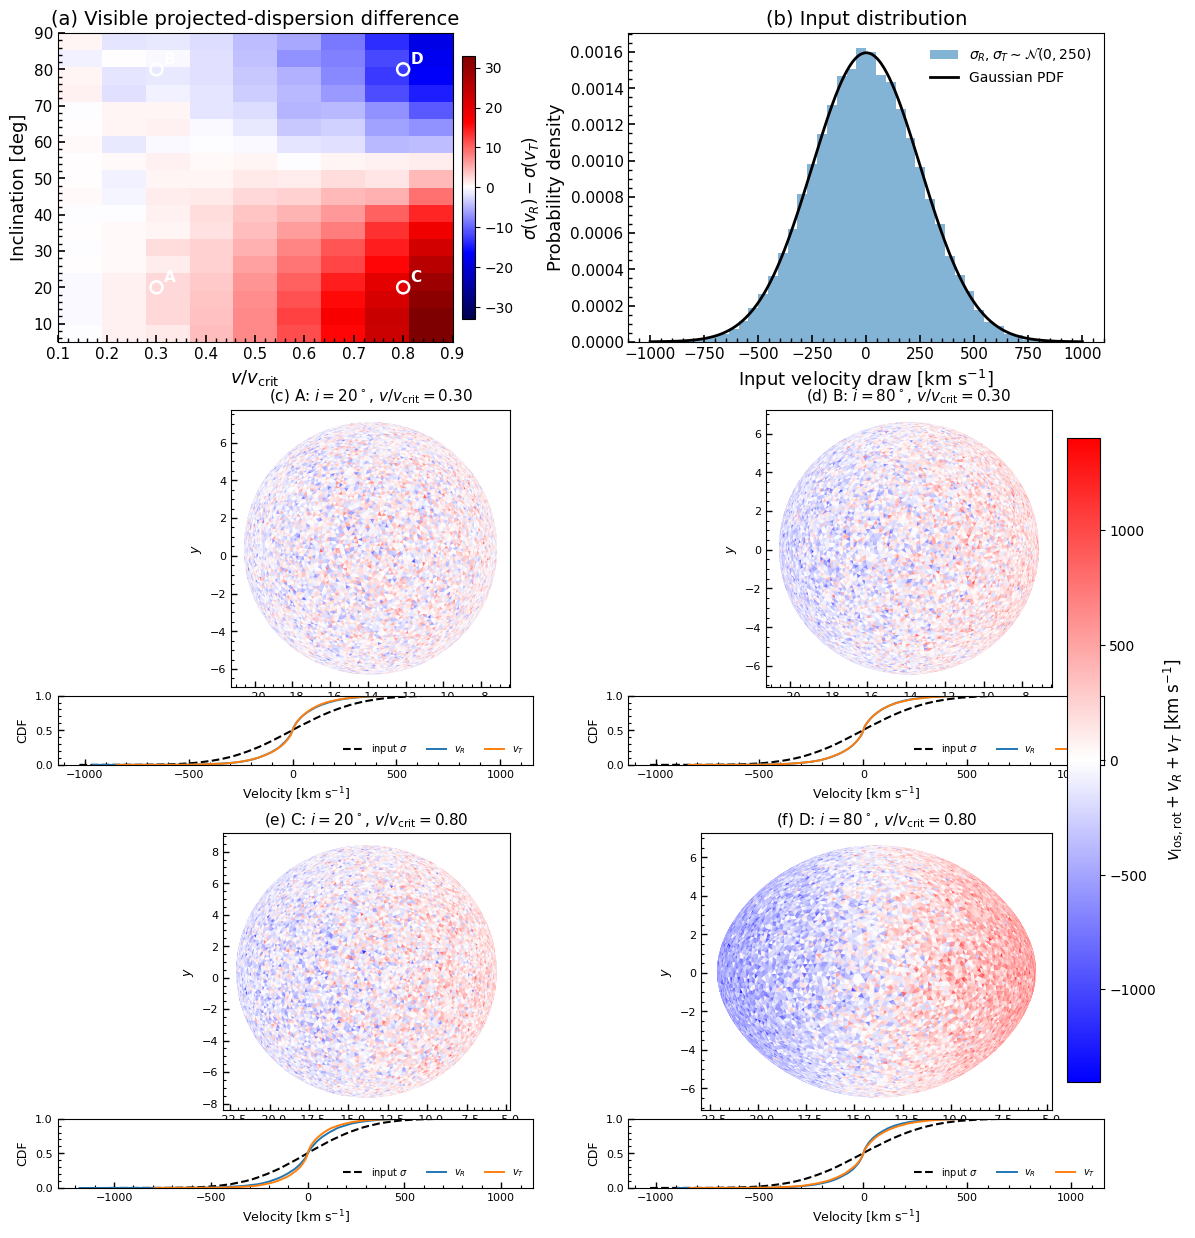

In [44]:
input_file = "/home/c4011027/PhD_stuff/SPAMMS/notebooks/input.txt"
df_csv = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/inclination_vcrit_sigma_grid.csv"

sample_cases = [
    {"label": "A", "inclination": 20, "v_crit_frac": 0.3},
    {"label": "B", "inclination": 80, "v_crit_frac": 0.3},
    {"label": "C", "inclination": 20, "v_crit_frac": 0.8},
    {"label": "D", "inclination": 80, "v_crit_frac": 0.8},
]

cases = plot_sigma_projection_summary(
    sp=sp,
    input_file=input_file,
    df_csv=df_csv,
    sample_cases=sample_cases,
    sigma0=250.0,
    seed=30,
    figsize=(13.5, 15.0)
)

In [43]:
cases

[{'inclination': 20,
  'v_crit_frac': 0.3,
  'sigma0': 250.0,
  'run_dictionary': {'v_macro': -1.0,
   'sigma_R': 200.0,
   'sigma_T': 200.0,
   'teff': 40000.0,
   'vsini': -1.0,
   'rotation_rate': -1.0,
   'v_crit_frac': 0.3,
   'requiv': -1.0,
   'r_pole': 6.5,
   'inclination': 20.0,
   'mass': 25.0,
   't0': 0.0,
   'gamma': 0.0,
   'run_id': 0},
  'phcb': <ParameterSet: 76 parameters | datasets: rv01, lc01, mesh01>,
  'polygons': array([[[-8.91530716e+06,  3.94787385e-01],
          [-8.91530716e+06,  1.57390198e-01],
          [-8.91530716e+06,  2.01263303e-01]],
  
         [[-8.91530716e+06,  3.94787385e-01],
          [-8.91530716e+06,  2.01263303e-01],
          [-8.91530716e+06,  4.38654785e-01]],
  
         [[-8.91530716e+06,  3.94787385e-01],
          [-8.91530716e+06,  4.38654785e-01],
          [-8.91530716e+06,  6.32184537e-01]],
  
         ...,
  
         [[-8.91531813e+06, -4.72175341e+00],
          [-8.91531844e+06, -4.43677818e+00],
          [-8.91531815e+06

### plotting

In [136]:
def plot_dynamic_heatmap_ax(ax, df, xaxis="inclination", yaxis="v_crit_frac", cbar_quantity="mean_sigma_vR_vis",
    cmap="viridis", xlabel=None, ylabel=None, cbar_label=None, title=None, symmetric_cbar=False,
    vmin=None, vmax=None, sample_points=None):

    d = df.copy()

    if callable(cbar_quantity):
        d["plot_value"] = cbar_quantity(d)
        value_name = "custom quantity"
    else:
        d["plot_value"] = d[cbar_quantity]
        value_name = cbar_quantity

    grid = d.pivot(index=yaxis, columns=xaxis, values="plot_value")
    xvals = grid.columns.values
    yvals = grid.index.values
    values = grid.values

    if vmin is not None or vmax is not None:
        final_vmin, final_vmax = vmin, vmax
    elif symmetric_cbar:
        absmax = np.nanmax(np.abs(values))
        final_vmin, final_vmax = -absmax, absmax
    else:
        final_vmin, final_vmax = None, None

    im = ax.imshow(values, origin="lower", aspect="auto", cmap=cmap,
                   extent=[xvals.min(), xvals.max(), yvals.min(), yvals.max()],
                   vmin=final_vmin, vmax=final_vmax)

    ax.set_xlabel(xlabel if xlabel else xaxis, fontsize=13)
    ax.set_ylabel(ylabel if ylabel else yaxis, fontsize=13)
    ax.tick_params(axis="both", which="major", labelsize=11, length=5, width=1.2, direction="in")
    ax.tick_params(axis="both", which="minor", length=3, width=1.0, direction="in")
    ax.minorticks_on()

    if title is not None:
        ax.set_title(title, fontsize=14)

    if sample_points is not None:
        for point in sample_points:
            ax.scatter(point["v_crit_frac"], point["inclination"],
                       s=80, facecolors="none", edgecolors="0.35",
                       linewidths=2.0, zorder=5)

            ax.text(point["v_crit_frac"] + 0.015, point["inclination"] + 1.5,
                    point["label"], color="0.2", fontsize=11, weight="bold",
                    zorder=6,
                    bbox=dict(boxstyle="round,pad=0.15", fc="0.9", ec="0.35", alpha=0.9))

    return im, cbar_label if cbar_label else value_name

In [137]:
def plot_input_distribution(ax, sigma0=250.0, seed=1234):
    rng = np.random.default_rng(seed)
    sigma_ref = rng.normal(0.0, sigma0, size=50000)

    bins = np.linspace(-4*sigma0, 4*sigma0, 45)
    ax.hist(sigma_ref, bins=bins, density=True, alpha=0.55, histtype="stepfilled",
            label=rf"$\sigma_R,\sigma_T \sim \mathcal{{N}}(0,{sigma0:.0f})$")

    x = np.linspace(-4*sigma0, 4*sigma0, 500)
    ax.plot(x, np.exp(-0.5*(x/sigma0)**2) / (sigma0*np.sqrt(2*np.pi)),
            lw=2.0, color="black", label="Gaussian PDF")

    ax.set_xlabel(r"Input velocity draw [km s$^{-1}$]", fontsize=13)
    ax.set_ylabel("Probability density", fontsize=13)


    ax.tick_params(axis="x", which="major", labelsize=11, length=5, width=1.2, direction="in")
    ax.tick_params(axis="x", which="minor", length=3, width=1.0, direction="in")
    ax.minorticks_on()

    # move y-axis to the right side
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.tick_params(axis="y", which="major", labelsize=11, length=5, width=1.2,
                   direction="in", right=True, labelright=True, left=False, labelleft=False)
    ax.tick_params(axis="y", which="minor", length=3, width=1.0,
                   direction="in", right=True, left=False)

    ax.legend(fontsize=10, frameon=False, loc="upper right")

    return sigma_ref

In [138]:


def plot_hist_panel(ax, case, sigma0=250.0, xlim=None, bins=35):
    inds = case["inds"]

    vr = case["v_R"][inds]
    vt = case["v_T"][inds]

    if xlim is None:
        vmax = np.nanmax(np.abs(np.concatenate([vr, vt])))
        xlim = (-1.05 * vmax, 1.05 * vmax)

    bins_arr = np.linspace(xlim[0], xlim[1], bins)

    # histograms
    ax.hist(vr, bins=bins_arr, density=True, histtype="step",
            linewidth=1.5, label=r"$v_R$")
    ax.hist(vt, bins=bins_arr, density=True, histtype="step",
            linewidth=1.5, label=r"$v_T$")

    ax.set_xlim(-400, 400)
    ax.set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=9)
    ax.set_ylabel("pdf", fontsize=9)

    ax.tick_params(axis="both", which="major", labelsize=8, length=4, width=1.0, direction="in")
    ax.tick_params(axis="both", which="minor", length=2, width=0.8, direction="in")
    ax.minorticks_on()

    ax.legend(fontsize=7, frameon=False, loc="upper right", ncol=1)

In [139]:
def plot_cdf_panel(ax, case, xlim=None):
    inds = case["inds"]

    x_r = np.sort(case["v_R"][inds])
    y_r = np.arange(1, len(x_r) + 1) / len(x_r)

    x_t = np.sort(case["v_T"][inds])
    y_t = np.arange(1, len(x_t) + 1) / len(x_t)

    ax.step(x_r, y_r, where="post", lw=1.6, label=r"$v_R$")
    ax.step(x_t, y_t, where="post", lw=1.6, label=r"$v_T$")

    if xlim is not None:
        ax.set_xlim(xlim)

    ax.set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=9)
    ax.set_ylabel("ECDF", fontsize=9)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", which="major", labelsize=8, length=4, width=1.0, direction="in")
    ax.tick_params(axis="both", which="minor", length=2, width=0.8, direction="in")
    ax.minorticks_on()

    ax.legend(fontsize=7, frameon=False, loc="lower right", ncol=2)

In [144]:
def plot_surface_panel(ax, case, norm, cmap="bwr", title=None):
    fc = case["v_tot"]
    inds = case["inds"]
    zinds = case["zinds"]
    polygons = case["polygons"]
    cmap_obj = cm.get_cmap(cmap)

    pc = PolyCollection(
        polygons[inds][zinds],
        facecolors=cmap_obj(norm(fc[inds][zinds])),
        edgecolors=cmap_obj(norm(fc[inds][zinds])),
        linewidths=0.10
    )

    ax.add_collection(pc)

    xvis = polygons[inds][:, :, 0]
    yvis = polygons[inds][:, :, 1]

    xmin, xmax = np.nanmin(xvis), np.nanmax(xvis)
    ymin, ymax = np.nanmin(yvis), np.nanmax(yvis)

    dx = xmax - xmin
    dy = ymax - ymin
    span = max(dx, dy)
    pad = 0.04 * span

    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)

    ax.set_xlim(xmid - 0.5 * span - pad, xmid + 0.5 * span + pad)
    ax.set_ylim(ymid - 0.5 * span - pad, ymid + 0.5 * span + pad)

    ax.set_aspect("equal")
    #ax.set_box_aspect(1)

    ax.set_xlabel(r"$x$", fontsize=9)
    ax.set_ylabel(r"$y$", fontsize=9)

    ax.tick_params(axis="both", which="major", labelsize=8, length=4, width=1.0, direction="in")
    ax.tick_params(axis="both", which="minor", length=2, width=0.8, direction="in")
    ax.minorticks_on()

    return pc

In [145]:
def plot_sigma_projection_summary_from_cases(
    cases, df_csv, sample_cases, sigma0=250.0,
    figsize=(13.5, 16.5),

    # Main figure geometry
    top_row_height=1.0,
    lower_row_height=1.85,
    left_col_width=1.0,
    right_col_width=1.0,

    # Spacing and margins
    left=0.065,
    right=0.90,
    bottom=0.045,
    top=0.975,
    wspace=0.28,
    hspace=0.18,

    # Internal geometry/CDF split
    surface_height=5.2,
    cdf_height=1.0,
    surface_cdf_hspace=0.045,

    # Manual colourbar control
    geom_cbar_x=0.925,
    geom_cbar_width=0.028,
):
    df = pd.read_csv(df_csv)

    vmax_geom = np.nanmax([
        np.nanmax(np.abs(case["v_tot"][case["inds"]]))
        for case in cases
    ])
    geom_norm = colors.Normalize(vmin=-vmax_geom, vmax=vmax_geom)

    vmax_cdf = np.nanmax(
        [np.nanmax(np.abs(case["v_R"][case["inds"]])) for case in cases] +
        [np.nanmax(np.abs(case["v_T"][case["inds"]])) for case in cases]
    )
    cdf_xlim = (-1.05 * vmax_cdf, 1.05 * vmax_cdf)

    fig = plt.figure(figsize=figsize)

    outer = fig.add_gridspec(
        3, 2,
        height_ratios=[top_row_height, lower_row_height, lower_row_height],
        width_ratios=[left_col_width, right_col_width],
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        wspace=wspace,
        hspace=hspace
    )

    # --------------------------------------------------------
    # Panel (a): heatmap
    # --------------------------------------------------------
    ax_heat = fig.add_subplot(outer[0, 0])

    im, heat_cbar_label = plot_dynamic_heatmap_ax(
        ax_heat,
        df,
        xaxis="v_crit_frac",
        yaxis="inclination",
        cbar_quantity=lambda d: d["mean_sigma_vR_vis"] - d["mean_sigma_vT_vis"],
        xlabel=r"$v/v_{\rm crit}$",
        ylabel="Inclination [deg]",
        cbar_label=r"$\sigma(v_R) - \sigma(v_T)$",
        cmap="seismic",
        symmetric_cbar=True,
        sample_points=sample_cases
    )

    cbar_heat = fig.colorbar(im, ax=ax_heat, shrink=0.83, pad=0.02)
    cbar_heat.set_label(heat_cbar_label, fontsize=12)
    cbar_heat.ax.tick_params(labelsize=10)

    # --------------------------------------------------------
    # Panel (b): input distribution
    # --------------------------------------------------------
    ax_input = fig.add_subplot(outer[0, 1])
    _ = plot_input_distribution(ax_input, sigma0=sigma0, seed=1234)

    # --------------------------------------------------------
    # Panels (c-f): surface + step-ECDF
    # --------------------------------------------------------
    surface_axes = []
    cdf_axes = []

    for k, grid_cell in enumerate([(1, 0), (1, 1), (2, 0), (2, 1)]):
        row, col = grid_cell

        sub = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[surface_height, cdf_height],
            hspace=surface_cdf_hspace
        )

        ax_surface = fig.add_subplot(sub[0, 0])
        ax_cdf = fig.add_subplot(sub[1, 0])

        case = cases[k]

        # no title here
        plot_surface_panel(ax_surface, case, geom_norm, cmap="bwr", title=None)

        # simple A/B/C/D label in top-left
        ax_surface.text(
            0.03, 0.97, case["label"],
            transform=ax_surface.transAxes,
            ha="left", va="top",
            fontsize=14, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.3", alpha=0.85)
        )

        plot_cdf_panel(ax_cdf, case, xlim=cdf_xlim)

        surface_axes.append(ax_surface)
        cdf_axes.append(ax_cdf)

    # --------------------------------------------------------
    # Force CDF panels to match surface-panel width
    # --------------------------------------------------------
    fig.canvas.draw()

    for ax_surface, ax_cdf in zip(surface_axes, cdf_axes):
        ps = ax_surface.get_position()
        pc = ax_cdf.get_position()
        ax_cdf.set_position([ps.x0, pc.y0, ps.width, pc.height])

    fig.canvas.draw()

    # --------------------------------------------------------
    # Manual geometry colourbar
    # --------------------------------------------------------
    surf_top = max(ax.get_position().y1 for ax in surface_axes)
    surf_bottom = min(ax.get_position().y0 for ax in surface_axes)

    cax = fig.add_axes([geom_cbar_x, surf_bottom, geom_cbar_width, surf_top - surf_bottom])

    sm = cm.ScalarMappable(norm=geom_norm, cmap="bwr")
    sm.set_array([])

    cbar_geom = fig.colorbar(sm, cax=cax)
    cbar_geom.set_label(r"$v_{\rm los,rot} + v_R + v_T$ [km s$^{-1}$]", fontsize=12)
    cbar_geom.ax.tick_params(labelsize=10)

    plt.show()

/tmp/ipykernel_7172/1922045912.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


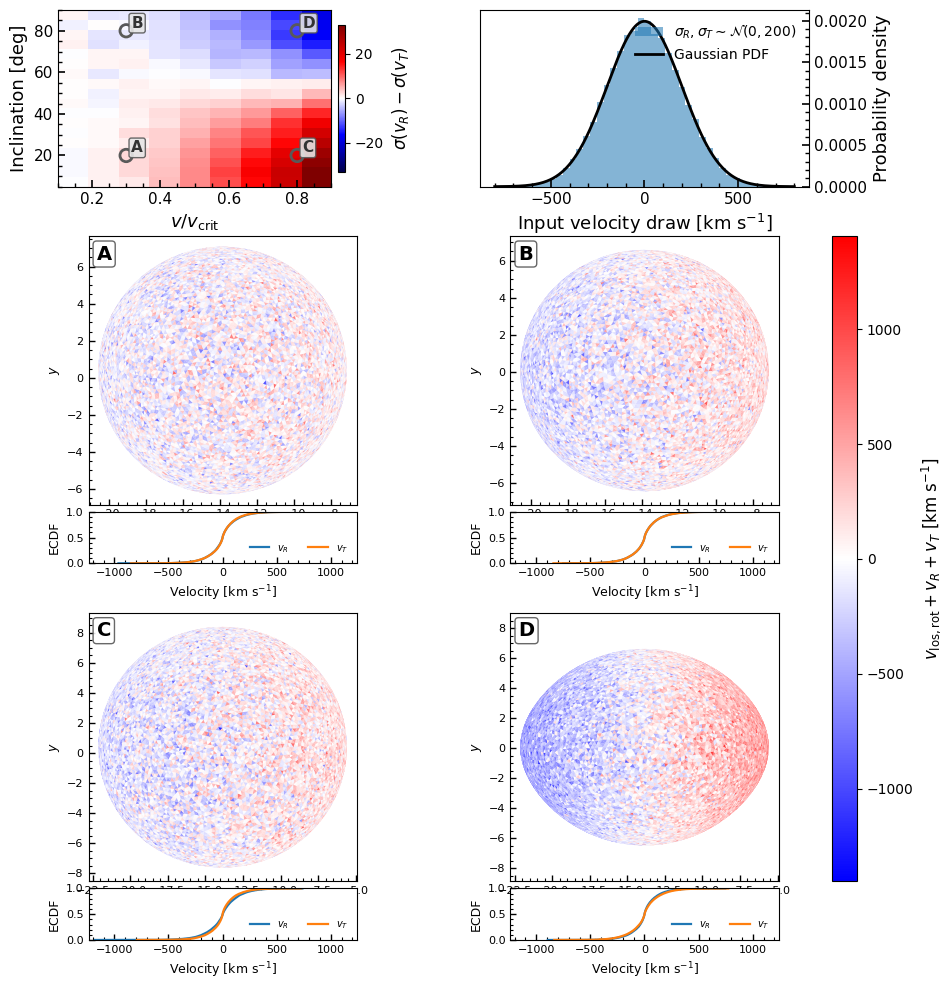

In [143]:
plot_sigma_projection_summary_from_cases(
    cases=cases,
    df_csv=df_csv,
    sample_cases=sample_cases,
    sigma0=200.0,
    figsize=(9, 10)
)

### new plot

/tmp/ipykernel_7172/3910387796.py:178: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


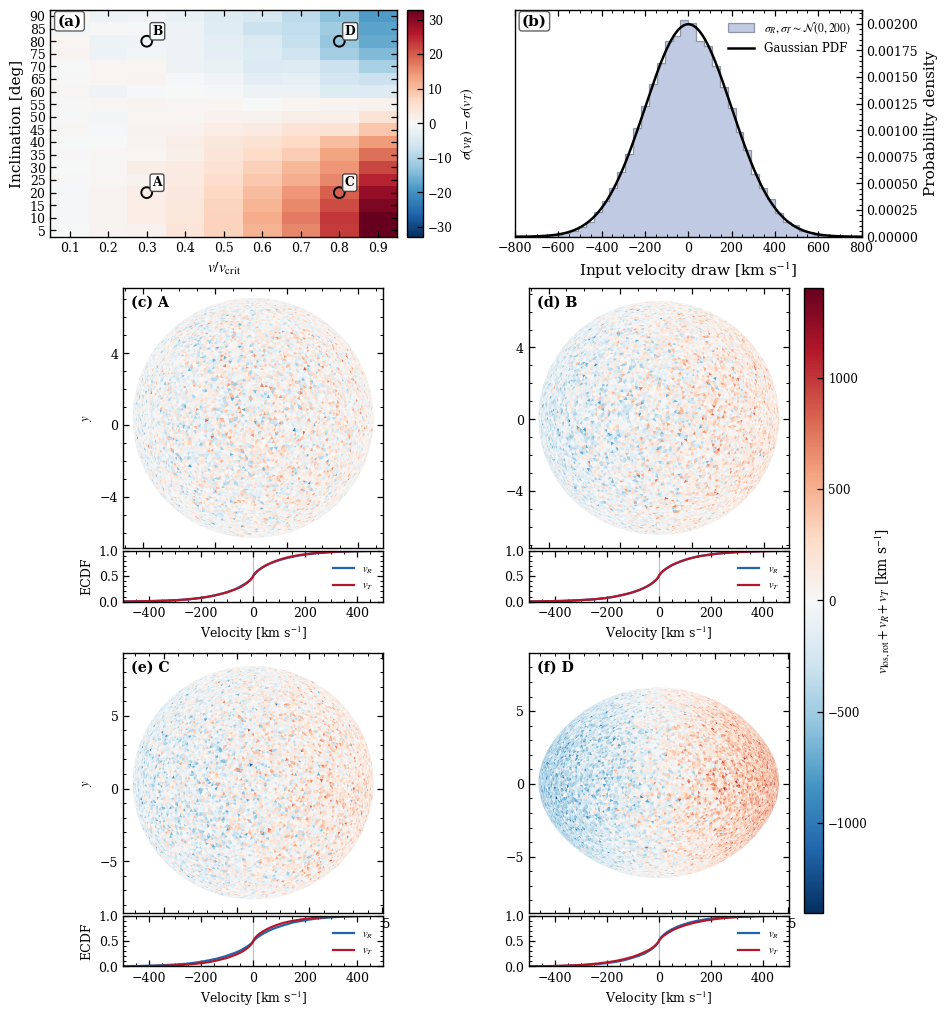

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.collections import PolyCollection
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def set_paper_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIX Two Text", "Times New Roman", "DejaVu Serif", "STIXGeneral"],
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.0,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.width": 0.7,
        "ytick.minor.width": 0.7,
        "legend.frameon": False,
        "savefig.dpi": 300
    })


def _cell_edges(vals):
    vals = np.asarray(vals, dtype=float)
    if len(vals) == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5])
    d = np.diff(vals)
    return np.concatenate(([vals[0] - d[0] / 2], vals[:-1] + d / 2, [vals[-1] + d[-1] / 2]))


def _ecdf(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    arr = np.sort(arr)
    y = np.arange(1, len(arr) + 1) / len(arr)
    return arr, y


def plot_dynamic_heatmap_ax(ax, df, xaxis="inclination", yaxis="v_crit_frac", cbar_quantity="mean_sigma_vR_vis",
    cmap="RdBu_r", xlabel=None, ylabel=None, cbar_label=None, title=None, symmetric_cbar=False,
    vmin=None, vmax=None, sample_points=None):

    d = df.copy()

    if callable(cbar_quantity):
        d["plot_value"] = cbar_quantity(d)
        value_name = "custom quantity"
    else:
        d["plot_value"] = d[cbar_quantity]
        value_name = cbar_quantity

    grid = d.pivot_table(index=yaxis, columns=xaxis, values="plot_value", aggfunc="mean")
    grid = grid.sort_index(axis=0).sort_index(axis=1)

    xvals = grid.columns.to_numpy(dtype=float)
    yvals = grid.index.to_numpy(dtype=float)
    values = grid.to_numpy(dtype=float)

    if vmin is not None or vmax is not None:
        final_vmin, final_vmax = vmin, vmax
    elif symmetric_cbar:
        absmax = np.nanmax(np.abs(values))
        final_vmin, final_vmax = -absmax, absmax
    else:
        final_vmin, final_vmax = None, None

    xedges = _cell_edges(xvals)
    yedges = _cell_edges(yvals)

    im = ax.pcolormesh(
        xedges, yedges, values,
        shading="auto", cmap=cmap, vmin=final_vmin, vmax=final_vmax,
        rasterized=True
    )

    ax.set_xlabel(xlabel if xlabel else xaxis)
    ax.set_ylabel(ylabel if ylabel else yaxis)
    ax.set_xticks(xvals)
    ax.set_yticks(yvals)
    ax.minorticks_off()

    if title is not None:
        ax.set_title(title, pad=6)

    if sample_points is not None and len(sample_points) > 0:
        dx = 0.018 * (xvals.max() - xvals.min())
        dy = 0.030 * (yvals.max() - yvals.min())

        for point in sample_points:
            x0 = point["v_crit_frac"]
            y0 = point["inclination"]

            ax.scatter(
                x0, y0, s=60, facecolors="none", edgecolors="black",
                linewidths=1.4, zorder=5
            )

            ax.text(
                x0 + dx, y0 + dy, point["label"],
                fontsize=8.8, weight="bold", color="black", zorder=6,
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.25", alpha=0.92)
            )

    return im, (cbar_label if cbar_label else value_name)


def plot_input_distribution(ax, sigma0=250.0, seed=1234):
    rng = np.random.default_rng(seed)
    sigma_ref = rng.normal(0.0, sigma0, size=50000)

    bins = np.linspace(-4 * sigma0, 4 * sigma0, 45)
    x = np.linspace(-4 * sigma0, 4 * sigma0, 600)
    pdf = np.exp(-0.5 * (x / sigma0) ** 2) / (sigma0 * np.sqrt(2 * np.pi))

    ax.hist(
        sigma_ref, bins=bins, density=True,
        histtype="stepfilled", alpha=0.55,
        color="#8da0cb", edgecolor="#4c566a", linewidth=0.9,
        label=rf"$\sigma_R,\sigma_T \sim \mathcal{{N}}(0,{sigma0:.0f})$"
    )
    ax.plot(x, pdf, lw=1.8, color="black", label="Gaussian PDF")

    ax.set_xlabel(r"Input velocity draw [km s$^{-1}$]")
    ax.set_ylabel("Probability density")
    ax.set_xlim(-4 * sigma0, 4 * sigma0)
    ax.minorticks_on()

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.tick_params(axis="y", right=True, labelright=True, left=False, labelleft=False)

    ax.legend(loc="upper right", fontsize=8.5, handlelength=2.2)
    return sigma_ref


def plot_cdf_panel(ax, case, xlim=None):
    inds = case["inds"]
    vr = np.asarray(case["v_R"])[inds]
    vt = np.asarray(case["v_T"])[inds]

    xr, yr = _ecdf(vr)
    xt, yt = _ecdf(vt)

    ax.step(xr, yr, where="post", lw=1.6, color="#2166ac", label=r"$v_R$")
    ax.step(xt, yt, where="post", lw=1.6, color="#b2182b", label=r"$v_T$")
    ax.axvline(0.0, color="0.75", lw=0.8, zorder=0)

    if xlim is not None:
        ax.set_xlim(-500, 500)

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=9)
    ax.set_ylabel("ECDF", fontsize=9)
    ax.minorticks_on()
    ax.legend(loc="lower right", fontsize=7.6, handlelength=2.0)


def plot_surface_panel(ax, case, norm, cmap="RdBu_r", title=None):
    fc = np.asarray(case["v_tot"])
    inds = np.asarray(case["inds"])
    zinds = np.asarray(case["zinds"])
    polygons = np.asarray(case["polygons"])

    cmap_obj = cm.get_cmap(cmap)

    pc = PolyCollection(
        polygons[inds][zinds],
        facecolors=cmap_obj(norm(fc[inds][zinds])),
        edgecolors="face",
        linewidths=0.0,
        rasterized=True
    )
    ax.add_collection(pc)

    xvis = polygons[inds][:, :, 0]
    yvis = polygons[inds][:, :, 1]

    xmin, xmax = np.nanmin(xvis), np.nanmax(xvis)
    ymin, ymax = np.nanmin(yvis), np.nanmax(yvis)

    dx = xmax - xmin
    dy = ymax - ymin
    span = max(dx, dy)
    pad = 0.04 * span

    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)

    ax.set_xlim(xmid - 0.5 * span - pad, xmid + 0.5 * span + pad)
    ax.set_ylim(ymid - 0.5 * span - pad, ymid + 0.5 * span + pad)
    ax.set_aspect("equal")

    ax.set_xlabel(r"$x$", fontsize=9)
    ax.set_ylabel(r"$y$", fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.minorticks_on()

    if title is not None:
        ax.set_title(title, pad=3, fontsize=9)

    return pc


def plot_sigma_projection_summary_from_cases(
    cases, df_csv, sample_cases, sigma0=250.0, figsize=(10.0, 10.8),
    left=0.065, right=0.91, bottom=0.055, top=0.975,
    top_row_height=1.05, lower_row_height=1.45,
    row_hspace=0.18, top_wspace=0.34, lower_wspace=0.0,
    surface_height=5.1, cdf_height=1.0, surface_cdf_hspace=0.018,
    geom_cbar_pad=0.016, geom_cbar_width=0.020
):
    set_paper_style()
    df = pd.read_csv(df_csv)

    vmax_geom = np.nanmax([np.nanmax(np.abs(np.asarray(case["v_tot"])[case["inds"]])) for case in cases])
    geom_norm = colors.Normalize(vmin=-vmax_geom, vmax=vmax_geom)

    vmax_cdf = np.nanmax(
        [np.nanmax(np.abs(np.asarray(case["v_R"])[case["inds"]])) for case in cases] +
        [np.nanmax(np.abs(np.asarray(case["v_T"])[case["inds"]])) for case in cases]
    )
    cdf_xlim = (-1.05 * vmax_cdf, 1.05 * vmax_cdf)

    fig = plt.figure(figsize=figsize)

    master = fig.add_gridspec(
        3, 1,
        height_ratios=[top_row_height, lower_row_height, lower_row_height],
        left=left, right=right, bottom=bottom, top=top,
        hspace=row_hspace
    )

    top_gs = master[0].subgridspec(1, 2, wspace=top_wspace, width_ratios=[1.0, 1.0])
    mid_gs = master[1].subgridspec(1, 2, wspace=lower_wspace, width_ratios=[1.0, 1.0])
    bot_gs = master[2].subgridspec(1, 2, wspace=lower_wspace, width_ratios=[1.0, 1.0])

    # --------------------------
    # (a) heatmap
    # --------------------------
    ax_heat = fig.add_subplot(top_gs[0, 0])

    im, heat_cbar_label = plot_dynamic_heatmap_ax(
        ax_heat,
        df,
        xaxis="v_crit_frac",
        yaxis="inclination",
        cbar_quantity=lambda d: d["mean_sigma_vR_vis"] - d["mean_sigma_vT_vis"],
        xlabel=r"$v/v_{\rm crit}$",
        ylabel="Inclination [deg]",
        cbar_label=r"$\sigma(v_R) - \sigma(v_T)$",
        cmap="RdBu_r",
        symmetric_cbar=True,
        sample_points=sample_cases
    )

    ax_heat.text(
        0.02, 0.98, "(a)",
        transform=ax_heat.transAxes, ha="left", va="top",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.35", alpha=0.95)
    )

    cax_heat = inset_axes(
        ax_heat, width="4.5%", height="100%", loc="lower left",
        bbox_to_anchor=(1.03, 0.0, 1, 1),
        bbox_transform=ax_heat.transAxes, borderpad=0
    )
    cbar_heat = fig.colorbar(im, cax=cax_heat)
    cbar_heat.set_label(heat_cbar_label, fontsize=10)
    cbar_heat.ax.tick_params(labelsize=8.5)

    # --------------------------
    # (b) input distribution
    # --------------------------
    ax_input = fig.add_subplot(top_gs[0, 1])
    plot_input_distribution(ax_input, sigma0=sigma0, seed=1234)

    ax_input.text(
        0.02, 0.98, "(b)",
        transform=ax_input.transAxes, ha="left", va="top",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.35", alpha=0.95)
    )

    # --------------------------
    # (c)-(f) lower panels
    # --------------------------
    lower_cells = [mid_gs[0, 0], mid_gs[0, 1], bot_gs[0, 0], bot_gs[0, 1]]
    letters = ["(c)", "(d)", "(e)", "(f)"]

    surface_axes, cdf_axes = [], []

    for k, cell in enumerate(lower_cells):
        sub = cell.subgridspec(
            2, 1,
            height_ratios=[surface_height, cdf_height],
            hspace=surface_cdf_hspace
        )

        ax_surface = fig.add_subplot(sub[0, 0])
        ax_cdf = fig.add_subplot(sub[1, 0])

        case = cases[k]

        plot_surface_panel(ax_surface, case, geom_norm, cmap="RdBu_r")
        plot_cdf_panel(ax_cdf, case, xlim=cdf_xlim)

        panel_text = f"{letters[k]} {case['label']}" if "label" in case else letters[k]
        ax_surface.text(
            0.03, 0.97, panel_text,
            transform=ax_surface.transAxes, ha="left", va="top",
            fontsize=10.2, fontweight="bold",
            #bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.35", alpha=0.92)
        )

        surface_axes.append(ax_surface)
        cdf_axes.append(ax_cdf)

    # make CDF panels exactly match surface widths
    fig.canvas.draw()
    for ax_surface, ax_cdf in zip(surface_axes, cdf_axes):
        ps = ax_surface.get_position()
        pc = ax_cdf.get_position()
        ax_cdf.set_position([ps.x0, pc.y0, ps.width, pc.height])

    # de-clutter right-column lower panels
    for ax in [surface_axes[1], surface_axes[3]]:
        ax.set_ylabel("")
    for ax in [cdf_axes[1], cdf_axes[3]]:
        ax.set_ylabel("")

    fig.canvas.draw()

    # shared colourbar for lower surface maps
    surf_top = max(ax.get_position().y1 for ax in surface_axes)
    surf_bottom = min(ax.get_position().y0 for ax in surface_axes)
    surf_right = max(ax.get_position().x1 for ax in surface_axes)

    cax = fig.add_axes([surf_right + geom_cbar_pad, surf_bottom, geom_cbar_width, surf_top - surf_bottom])
    sm = cm.ScalarMappable(norm=geom_norm, cmap="RdBu_r")
    sm.set_array([])

    cbar_geom = fig.colorbar(sm, cax=cax)
    cbar_geom.set_label(r"$v_{\rm los,rot}+v_R+v_T$ [km s$^{-1}$]", fontsize=10)
    cbar_geom.ax.tick_params(labelsize=8.5)

    plt.show()


plot_sigma_projection_summary_from_cases(
    cases=cases,
    df_csv=df_csv,
    sample_cases=sample_cases,
    sigma0=200.0,
    figsize=(9.6, 10.4)
)

/tmp/ipykernel_7172/1629202040.py:236: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


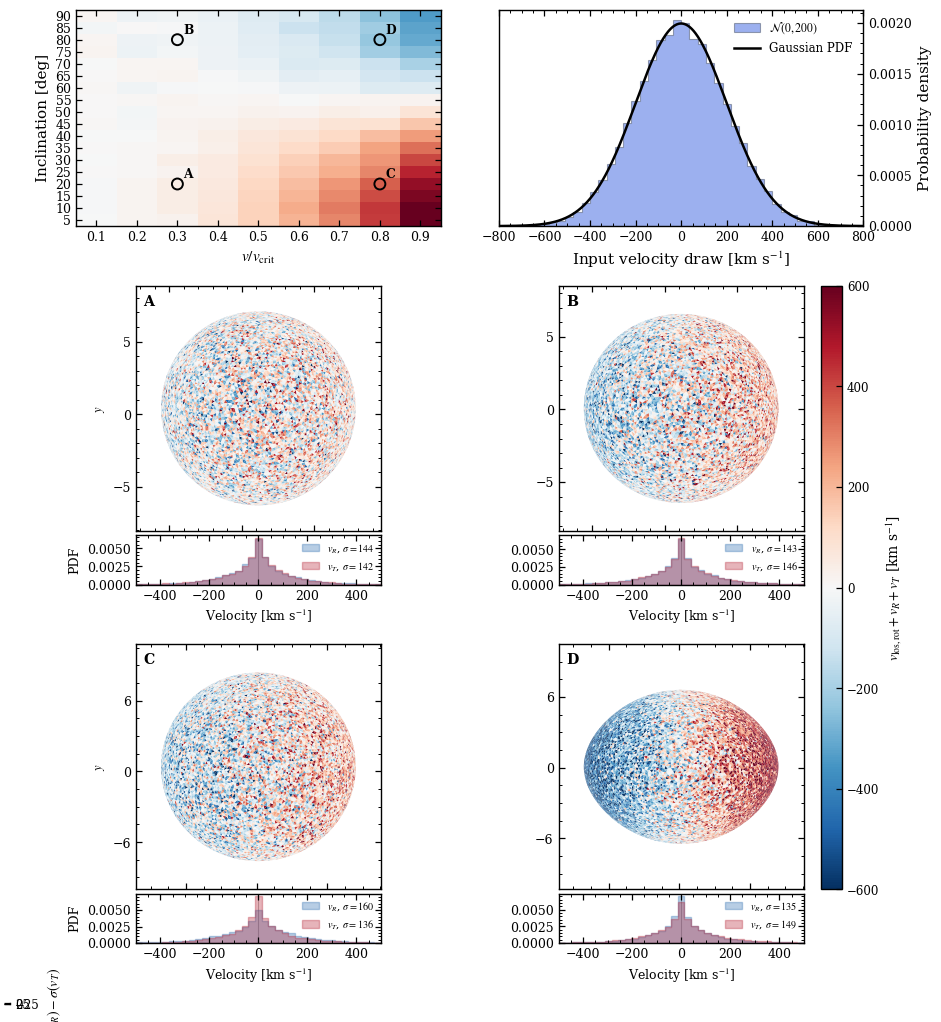

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.collections import PolyCollection
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def set_paper_style():
    plt.rcParams.update({
        "axes.linewidth": 1.0,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.width": 0.7,
        "ytick.minor.width": 0.7,
        "legend.frameon": False,
        "savefig.dpi": 300
    })


def _cell_edges(vals):
    vals = np.asarray(vals, dtype=float)

    if len(vals) == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5])

    d = np.diff(vals)
    return np.concatenate(([vals[0] - d[0] / 2], vals[:-1] + d / 2, [vals[-1] + d[-1] / 2]))


def _gaussian_pdf(x, mu, sigma):
    if not np.isfinite(sigma) or sigma <= 0:
        return np.full_like(x, np.nan)

    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def plot_dynamic_heatmap_ax(ax, df, xaxis="inclination", yaxis="v_crit_frac", cbar_quantity="mean_sigma_vR_vis",
    cmap="RdBu_r", xlabel=None, ylabel=None, cbar_label=None, title=None, symmetric_cbar=False,
    vmin=None, vmax=None, sample_points=None):

    d = df.copy()

    if callable(cbar_quantity):
        d["plot_value"] = cbar_quantity(d)
        value_name = "custom quantity"
    else:
        d["plot_value"] = d[cbar_quantity]
        value_name = cbar_quantity

    grid = d.pivot_table(index=yaxis, columns=xaxis, values="plot_value", aggfunc="mean")
    grid = grid.sort_index(axis=0).sort_index(axis=1)

    xvals = grid.columns.to_numpy(dtype=float)
    yvals = grid.index.to_numpy(dtype=float)
    values = grid.to_numpy(dtype=float)

    if vmin is not None or vmax is not None:
        final_vmin, final_vmax = vmin, vmax
    elif symmetric_cbar:
        absmax = np.nanmax(np.abs(values))
        final_vmin, final_vmax = -absmax, absmax
    else:
        final_vmin, final_vmax = None, None

    xedges = _cell_edges(xvals)
    yedges = _cell_edges(yvals)

    im = ax.pcolormesh(
        xedges, yedges, values,
        shading="auto",
        cmap=cmap,
        vmin=final_vmin,
        vmax=final_vmax,
        rasterized=True
    )

    ax.set_xlabel(xlabel if xlabel else xaxis)
    ax.set_ylabel(ylabel if ylabel else yaxis)
    ax.set_xticks(xvals)
    ax.set_yticks(yvals)
    ax.minorticks_off()

    if title is not None:
        ax.set_title(title, pad=6)

    if sample_points is not None and len(sample_points) > 0:
        dx = 0.018 * (xvals.max() - xvals.min())
        dy = 0.030 * (yvals.max() - yvals.min())

        for point in sample_points:
            x0 = point["v_crit_frac"]
            y0 = point["inclination"]

            ax.scatter(
                x0, y0,
                s=62,
                facecolors="none",
                edgecolors="black",
                linewidths=1.4,
                zorder=5
            )

            ax.text(
                x0 + dx, y0 + dy, point["label"],
                fontsize=8.8,
                weight="bold",
                color="black",
                zorder=6,
                #bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.25", alpha=0.92)
            )

    return im, cbar_label if cbar_label else value_name


def plot_input_distribution(ax, sigma0=250.0, seed=1234):
    rng = np.random.default_rng(seed)
    sigma_ref = rng.normal(0.0, sigma0, size=50000)

    bins = np.linspace(-4 * sigma0, 4 * sigma0, 45)
    x = np.linspace(-4 * sigma0, 4 * sigma0, 600)
    pdf = _gaussian_pdf(x, 0.0, sigma0)

    ax.hist(
        sigma_ref,
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=0.52,
        color="royalblue",
        edgecolor="#4c566a",
        linewidth=0.8,
        label=rf"$\mathcal{{N}}(0,{sigma0:.0f})$"
    )

    ax.plot(
        x, pdf,
        lw=1.8,
        color="black",
        label="Gaussian PDF"
    )

    ax.set_xlabel(r"Input velocity draw [km s$^{-1}$]")
    ax.set_ylabel("Probability density")
    ax.set_xlim(-4 * sigma0, 4 * sigma0)
    ax.minorticks_on()

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.tick_params(axis="y", right=True, labelright=True, left=False, labelleft=False)

    ax.legend(loc="upper right", fontsize=8.5, handlelength=2.2)

    return sigma_ref


def plot_hist_panel(ax, case, xlim=None, bins=36):
    inds = case["inds"]

    vr = np.asarray(case["v_R"])[inds]
    vt = np.asarray(case["v_T"])[inds]

    vr = vr[np.isfinite(vr)]
    vt = vt[np.isfinite(vt)]

    if xlim is None:
        vmax = np.nanmax(np.abs(np.concatenate([vr, vt])))
        xlim = (-1.08 * vmax, 1.08 * vmax)

    bins_arr = np.linspace(xlim[0], xlim[1], bins)
    x = np.linspace(xlim[0], xlim[1], 600)

    mu_r, sig_r = np.nanmean(vr), np.nanstd(vr)
    mu_t, sig_t = np.nanmean(vt), np.nanstd(vt)

    ax.hist(
        vr,
        bins=bins_arr,
        density=True,
        histtype="stepfilled",
        alpha=0.32,
        color="#2166ac",
        edgecolor="#2166ac",
        linewidth=1.0,
        label=rf"$v_R$, $\sigma={sig_r:.0f}$"
    )

    ax.hist(
        vt,
        bins=bins_arr,
        density=True,
        histtype="stepfilled",
        alpha=0.32,
        color="#b2182b",
        edgecolor="#b2182b",
        linewidth=1.0,
        label=rf"$v_T$, $\sigma={sig_t:.0f}$"
    )

    ax.axvline(0.0, color="0.72", lw=0.8, zorder=0)

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Velocity [km s$^{-1}$]", fontsize=9)
    ax.set_ylabel("PDF", fontsize=9)

    ax.yaxis.set_major_locator(MaxNLocator(3))
    ax.minorticks_on()

    ax.legend(
        loc="upper right",
        fontsize=7.3,
        handlelength=1.7,
        borderaxespad=0.2
    )


def plot_surface_panel(ax, case, norm, cmap="RdBu_r", title=None, surface_pad_frac=0.12):
    fc = np.asarray(case["v_tot"])
    inds = np.asarray(case["inds"])
    zinds = np.asarray(case["zinds"])
    polygons = np.asarray(case["polygons"])

    cmap_obj = cm.get_cmap(cmap)

    pc = PolyCollection(
        polygons[inds][zinds],
        facecolors=cmap_obj(norm(fc[inds][zinds])),
        edgecolors="face",
        linewidths=0.0,
        rasterized=True
    )

    ax.add_collection(pc)

    xvis = polygons[inds][:, :, 0]
    yvis = polygons[inds][:, :, 1]

    xmin, xmax = np.nanmin(xvis), np.nanmax(xvis)
    ymin, ymax = np.nanmin(yvis), np.nanmax(yvis)

    dx = xmax - xmin
    dy = ymax - ymin
    span = max(dx, dy)

    pad = surface_pad_frac * span

    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)

    ax.set_xlim(xmid - 0.5 * span - pad, xmid + 0.5 * span + pad)
    ax.set_ylim(ymid - 0.5 * span - pad, ymid + 0.5 * span + pad)

    ax.set_aspect("equal")
    #ax.set_anchor("C")

    ax.set_xlabel(r"$x$", fontsize=9)
    ax.set_ylabel(r"$y$", fontsize=9)

    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))

    ax.minorticks_on()

    if title is not None:
        ax.set_title(title, pad=3, fontsize=9)

    return pc


def plot_sigma_projection_summary_from_cases(
    cases,
    df_csv,
    sample_cases,
    sigma0=250.0,
    figsize=(9.6, 10.2),

    left=0.070,
    right=0.890,
    bottom=0.060,
    top=0.975,

    row_hspace=0.22,
    col_wspace=0.16,

    top_row_height=1.0,
    lower_row_height=1.38,

    surface_height=5.0,
    hist_height=1.0,
    surface_hist_hspace=0.030,

    surface_pad_frac=0.12,

    geom_vmin=-400.0,
    geom_vmax=400.0,
    geom_cbar_pad=0.018,
    geom_cbar_width=0.022
):
    set_paper_style()

    df = pd.read_csv(df_csv)

    geom_norm = colors.Normalize(vmin=geom_vmin, vmax=geom_vmax)

    vmax_hist = np.nanmax(
        [np.nanmax(np.abs(np.asarray(case["v_R"])[case["inds"]])) for case in cases] +
        [np.nanmax(np.abs(np.asarray(case["v_T"])[case["inds"]])) for case in cases]
    )
    hist_xlim = (-1.08 * vmax_hist, 1.08 * vmax_hist)

    fig = plt.figure(figsize=figsize)

    outer = fig.add_gridspec(
        3, 2,
        height_ratios=[top_row_height, lower_row_height, lower_row_height],
        width_ratios=[1.0, 1.0],
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        hspace=row_hspace,
        wspace=col_wspace
    )

    # --------------------------------------------------------
    # Panel (a): heatmap
    # --------------------------------------------------------
    ax_heat = fig.add_subplot(outer[0, 0])

    im, heat_cbar_label = plot_dynamic_heatmap_ax(
        ax_heat,
        df,
        xaxis="v_crit_frac",
        yaxis="inclination",
        cbar_quantity=lambda d: d["mean_sigma_vR_vis"] - d["mean_sigma_vT_vis"],
        xlabel=r"$v/v_{\rm crit}$",
        ylabel="Inclination [deg]",
        cbar_label=r"$\sigma(v_R) - \sigma(v_T)$",
        cmap="RdBu_r",
        symmetric_cbar=True,
        sample_points=sample_cases
    )


    cax_heat = inset_axes(
        ax_heat,
        width="4.6%",
        height="100%",
        loc="lower left",
        bbox_to_anchor=(1.035, 0.0, 1, 1),
        #bbox_transform=ax_heat.transAxes,
        borderpad=0
    )

    cbar_heat = fig.colorbar(im, cax=cax_heat)
    cbar_heat.set_label(heat_cbar_label, fontsize=10)
    cbar_heat.ax.tick_params(labelsize=8.5)

    # --------------------------------------------------------
    # Panel (b): input distribution
    # --------------------------------------------------------
    ax_input = fig.add_subplot(outer[0, 1])

    plot_input_distribution(
        ax_input,
        sigma0=sigma0,
        seed=1234
    )

    # --------------------------------------------------------
    # Panels (c-f): surface map + histogram
    # --------------------------------------------------------
    lower_cells = [
        outer[1, 0],
        outer[1, 1],
        outer[2, 0],
        outer[2, 1]
    ]

    letters = ["(c)", "(d)", "(e)", "(f)"]

    surface_axes = []
    hist_axes = []

    for k, cell in enumerate(lower_cells):
        sub = cell.subgridspec(
            2, 1,
            height_ratios=[surface_height, hist_height],
            hspace=surface_hist_hspace
        )

        ax_surface = fig.add_subplot(sub[0, 0])
        ax_hist = fig.add_subplot(sub[1, 0])

        case = cases[k]

        plot_surface_panel(
            ax_surface,
            case,
            geom_norm,
            cmap="RdBu_r",
            surface_pad_frac=surface_pad_frac
        )

        plot_hist_panel(
            ax_hist,
            case,
            xlim=(-500, 500),
            bins=38
        )

        panel_label = f"{case['label']}" if "label" in case else letters[k]

        ax_surface.text(
            0.030, 0.965,
            panel_label,
            transform=ax_surface.transAxes,
            ha="left",
            va="top",
            fontsize=10.2,
            fontweight="bold",
            #bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.35", alpha=0.92)
        )

        surface_axes.append(ax_surface)
        hist_axes.append(ax_hist)

    # --------------------------------------------------------
    # Align histogram panels with their surface panels
    # --------------------------------------------------------
    fig.canvas.draw()

    for ax_surface, ax_hist in zip(surface_axes, hist_axes):
        ps = ax_surface.get_position()
        ph = ax_hist.get_position()
        ax_hist.set_position([ps.x0, ph.y0, ps.width, ph.height])

    # reduce duplicated labels on right column
    for ax in [surface_axes[1], surface_axes[3]]:
        ax.set_ylabel("")

    for ax in [hist_axes[1], hist_axes[3]]:
        ax.set_ylabel("")

    # reduce duplicated x labels on upper lower-row surfaces
    for ax in surface_axes:
        ax.set_xlabel(r"$x$")

    fig.canvas.draw()

    # --------------------------------------------------------
    # Shared colourbar for surface maps
    # --------------------------------------------------------
    surf_top = max(ax.get_position().y1 for ax in surface_axes)
    surf_bottom = min(ax.get_position().y0 for ax in surface_axes)
    surf_right = max(ax.get_position().x1 for ax in surface_axes)

    cax = fig.add_axes([
        surf_right + geom_cbar_pad,
        surf_bottom,
        geom_cbar_width,
        surf_top - surf_bottom
    ])

    sm = cm.ScalarMappable(norm=geom_norm, cmap="RdBu_r")
    sm.set_array([])

    cbar_geom = fig.colorbar(sm, cax=cax)
    cbar_geom.set_label(
        r"$v_{\rm los,rot}+v_R+v_T$ [km s$^{-1}$]",
        fontsize=10
    )
    cbar_geom.ax.tick_params(labelsize=8.5)

    plt.show()


plot_sigma_projection_summary_from_cases(
    cases=cases,
    df_csv=df_csv,
    sample_cases=sample_cases,
    sigma0=200.0,
    figsize=(9.6, 10.2),
    surface_pad_frac=0.13,
    geom_vmin=-600.0,
    geom_vmax= 600.0
)